## Non-moral budget experiment

This notebook varies the Lost Insulin budget and compares runtime with policy worth for utility, cost, legality, and necessity configurations.

Execution order:

1. Define configurations across the budget range.
2. Build and run environments.
3. Read winning-policy and timing fields into a repetition-level DataFrame.
4. Plot runtime against budget.
5. Load policy-level worth data and plot normalised worth against budget.


In [78]:
from scripts.AbstractExperiments import ExperimentRunner
from scripts.TexTables import SaveDataFrameToTexTemplate
from copy import deepcopy
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt


plt.rcParams.update({
    "font.family": "Charter",
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})

def latex_config_name(name):
    return "$" + name.replace("^0", "^{0}") + "$"


def QuickPlotGraph(df_, configs:list, 
                   independent_var:str, 
                   dependent_var:str, 
                   title:str=None, 
                   ind_label:str=None, 
                   dep_label:str=None, 
                   file_out:str=None, 
                   regression:bool=False, 
                   regression_label:bool=False,
                   fig_size:tuple=(8,6),
                   log_scale=True,
                   colors:dict={}
                   ):
    if ind_label is None:
        ind_label = independent_var
    if dep_label is None:
        dep_label = dependent_var
        
    df_a = df_.copy()
    df_a = df_a[df_a['Config_name'].isin(configs)]
    df_aa = (
        df_a
        .groupby(["Config_name", independent_var], as_index=False)[dependent_var]
        .mean()
        .sort_values(["Config_name", independent_var])
    )

    regression_results = {}
    regression_text = []

    fig, ax = plt.subplots(figsize=fig_size)
    for c, g in df_aa.groupby('Config_name', sort=False):
        x = g[independent_var].to_numpy(dtype=float)
        y = g[dependent_var].to_numpy(dtype=float)
        ax.scatter(x, y, alpha=0.75, label=latex_config_name(c))
        observed_line, = ax.plot(x, y, alpha=0.75, color = colors[c] if c in colors.keys() else None)

        if regression:
            # log(y) is only defined for strictly positive y values.
            valid = (np.isfinite(x) & np.isfinite(y) & (y > 0))
            x_valid = x[valid]
            y_valid = y[valid]
            
            log_y = np.log(y_valid)

            # log(y) = intercept + growth_rate * x
            growth_rate, intercept = np.polyfit(x_valid, log_y, deg=1)

            scale = np.exp(intercept)

            predicted_log_y = (intercept + growth_rate * x_valid)

            residual_sum_of_squares = np.sum((log_y - predicted_log_y) ** 2)
            total_sum_of_squares = np.sum((log_y - log_y.mean()) ** 2)

            if np.isclose(total_sum_of_squares, 0):
                r_squared = np.nan
            else:
                r_squared = (1 - residual_sum_of_squares / total_sum_of_squares)

            regression_results[c] = { "a": scale, "b": growth_rate, "R_squared": r_squared}

            # Use a dense x range to draw a smooth exponential curve.
            regression_x = np.linspace(x_valid.min(), x_valid.max(), 200,)
            regression_y = scale * np.exp(growth_rate * regression_x) 

            ax.plot(
                regression_x,
                regression_y,
                linestyle="--",
                linewidth=2,
                alpha=0.9,
                color=observed_line.get_color(),
                label='__nolegend__',)
            
            regression_text.append(
                rf"{latex_config_name(c)}: "
                rf"$y={scale:.3g}e^{{{growth_rate:.3g}x}}$, "
                rf"$R^2={r_squared:.4f}$"
            )
    if log_scale:
        plt.yscale('log')  # Set the y-axis to logarithmic scale
    if (title is None):
        plt.title(f"{ind_label} vs {dep_label}")
    else:
        plt.title(title)

    plt.xlabel(ind_label)
    plt.ylabel(dep_label)

    ax.grid(True, alpha=0.3)
    ax.legend(title="Config", loc='upper left')

    if regression and regression_text and regression_label:
        regression_summary = "\n".join(regression_text)
        # Position the regression summary outside the plotting region.
        ax.text(1.03, 0.98, regression_summary,
            transform=ax.transAxes, va="top", ha="left",
            fontsize=11, linespacing=1.4,
            bbox={"boxstyle": "round,pad=0.5", "facecolor": "white", "edgecolor": "0.7", "alpha": 0.9,},
        )
        # Reserve space on the right for the summary.
        fig.subplots_adjust(right=0.68)
    else:
        fig.tight_layout()

    plt.tight_layout() 
    if (not file_out is None):
        plt.savefig(f"{file_out}")
    plt.show()  # Show the plot
    

## Budget-dependent configurations

**nonMoralConfigs** defines the theory and consideration combinations. The loop expands each definition over budgets from 3 up to 8 in increments of 0.25.

Each entry in **configs** contains a budget-prefixed Name, the fixed/default Horizon, and the associated theories and considerations. **Config_repetitions** and **Environment_repetitions** control repeated runs.


In [63]:
defaultConfig = {"Horizon": 6}

nonMoralConfigs = {
    "(C)": {"Theories": [["Carla", "Utility", 0]], "Considerations": [["Carla", "Carla"], ["Cost"]]},
    "(AU)": {"Theories": [["AU", "Utility", 0]], "Considerations": [["Carla", "AU"], ["Hal", "AU"], ["Cost"]]},
    "(C)^0, (AU)^0": {
        "Theories": [["AU", "Utility", 0], ["Carla", "Utility", 0]], 
        "Considerations": [["Carla", ["AU", "Carla"]], ["Hal", "AU"], ["Cost"]]
    },
    "(N)": {
        "Theories": [["Necessity", "Ordinal", 0]], 
        "Considerations": [["Necessity", "Necessity"], ["Cost"]]
    },
    "(L)": {
        "Theories": [["OrdinalLaw", "Ordinal", 0]], 
        "Considerations": [["OrdinalLaw", "OrdinalLaw"], ["Cost"]]
    },
    "(L)^0, (N)^0": {
        "Theories": [["Necessity", "Ordinal", 0], ["OrdinalLaw", "Ordinal", 0]], 
        "Considerations": [["Necessity", "Necessity"], ["OrdinalLaw", "OrdinalLaw"], ["Cost"]]
    },
    "(C)^0, (N)^0, (L)^0": {
        "Theories": [["Necessity", "Ordinal", 0], ["OrdinalLaw", "Ordinal", 0], ["Carla", "Utility", 0]], 
        "Considerations": [["Necessity", "Necessity"], ["OrdinalLaw", "OrdinalLaw"], ["Cost"], ["Carla", "Carla"]]
    },
    "(C)^0, (AU)^0, (N)^0, (L)^0": {
        "Theories": [["Necessity", "Ordinal", 0], ["OrdinalLaw", "Ordinal", 0], ["Carla", "Utility", 0], ["AU", "Utility", 0]], 
        "Considerations": [["Necessity", "Necessity"], ["OrdinalLaw", "OrdinalLaw"], ["Cost"], ["Carla", ["AU", "Carla"]]]
    },
}

Config_repetitions=1
Environment_repetitions = 10

configs = []

min_budget = 3
step = 0.25
max_budget = 8
budget = min_budget
while (budget < max_budget):
    for name, dat in nonMoralConfigs.items():
        c = deepcopy(defaultConfig)
        c["Name"] = f"{budget}_{name}"
        c["Theories"] = dat["Theories"]
        c["Considerations"] = dat["Considerations"]
        c["Budget"] = budget
        c["Horizon"] = dat["Horizon"] if "Horizon" in dat.keys() else c["Horizon"]
        configs.append(c)
    budget += step

## Experiment runner

**er** manages the NonMoral experiment files. The environment-building and planner cells write raw JSON for every configuration, budget, and repetition.

These cells are expensive and only need rerunning when inputs or planner behaviour change.


In [64]:
er = ExperimentRunner("LostInsulin", configs, MoralPlanner_Location="/../../", outFolder="NonMoral")

In [65]:
envs = er.buildEnvironments(configRepetitions=1)
er.runPlanner(configRepetitions=Config_repetitions, envRepetitions=Environment_repetitions)

Written LostInsulin MMMDP with 689 states and theories [{'Name': 'Carla', 'Type': 'Utility', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/LostInsulin/../../Data/Experiments/LostInsulin/NonMoral/mdps/3_(C)_con0.json

Written LostInsulin MMMDP with 689 states and theories [{'Name': 'AU', 'Type': 'Utility', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/LostInsulin/../../Data/Experiments/LostInsulin/NonMoral/mdps/3_(AU)_con0.json

Written LostInsulin MMMDP with 689 states and theories [{'Name': 'AU', 'Type': 'Utility', 'Rank': 0}, {'Name': 'Carla', 'Type': 'Utility', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/LostInsulin/../../Data/Experiments/LostInsulin/NonMoral/mdps/3_(C)^0, (AU)^0_con0.json

Written LostInsulin MMMDP with 689 states and theories [{'Name': 'Necessity', 'Type': 'Ordinal', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/LostInsulin/../../Data/Experiments/LostInsulin/NonMoral/mdps/3_(N)_con0.

## Winning-policy and timing DataFrame

The raw JSON loop creates **df** with one row per configuration/environment repetition.

| Column group | Contents |
|---|---|
| Identifiers | Config_name, Env_rep, Horizon, Budget |
| Timing | Heuristic, Plan, Solution Extraction, MEHR, Total |
| Search results | Solutions and Total policies |
| Winning-policy worth | Cost, Carla, Legal, and Necessity |

The budget prefix is parsed into a numeric Budget column and removed from Config_name.


In [72]:
data = []
for c in configs:
    for env_rep in range(Environment_repetitions):
        # Assuming self.makePlanOutFileName exists
        outFile = er.makePlanOutFileName(c["Name"], 0, env_rep)
        with open(outFile, 'r') as file:
            json_data = json.load(file)
            x = json_data["Solutions"][json_data["Solutions_Order"][0]]["Expectation"]
            e = {
                "Config_name": c["Name"],
                "Env_rep" : env_rep,
                "Horizon": json_data["Horizon"],
                "Heuristic": json_data["Duration_Heuristic"],
                "Plan": json_data["Duration_Plan"],
                "Solution Extraction": json_data["Duration_Sols"],
                "MEHR": json_data["Duration_MEHR"],
                "Total" : json_data["Duration_Total"],
                "Total" : json_data["Duration_Total"],
                "Solutions" : len(json_data["Solutions"]),
                "Total policies": json_data["Total_reachable_policies"],
                "Cost": np.float32(x["Cost"]),
                "Carla": np.float32(x["Carla"]) if "Carla" in x.keys() else np.nan,
                "Legal": x["Legal"] if "Legal" in x.keys() else np.nan,
                "Necessity": x["Necessity"] if "Necessity" in x.keys() else np.nan,
            }
            data.append(e)
time_cols = ["Heuristic", "Plan", "Solution Extraction", "MEHR", "Total"]
df = pd.DataFrame(data)

df["Cost"] = pd.to_numeric(df["Cost"])
df["Budget"] = pd.to_numeric(
    df["Config_name"]
    .str.extract(r"^(\d+(?:\.\d+)?)_", expand=False)
    .astype(float))
df["Config_name"] = df["Config_name"].str.replace(
    r"^\d+(?:\.\d+)?_",
    "",
    regex=True
)
df

,Config_name,Env_rep,Horizon,Heuristic,Plan,Solution Extraction,MEHR,Total,Solutions,Total policies,Cost,Carla,Legal,Necessity,Budget
0,(C),0,7,255,92,108,0,455,1,507068,-2.7600,-39.105,NaN,NaN,3.00
1,(C),1,7,244,91,104,0,439,1,507068,-2.7600,-39.105,NaN,NaN,3.00
2,(C),2,7,295,112,137,0,544,1,507068,-2.7600,-39.105,NaN,NaN,3.00
3,(C),3,7,314,114,130,0,558,1,507068,-2.7600,-39.105,NaN,NaN,3.00
4,(C),4,7,296,114,130,0,540,1,507068,-2.7600,-39.105,NaN,NaN,3.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,"(C)^0, (AU)^0, (N)^0, (L)^0",5,7,661,25450,17298,869,44278,76,507068,-4.2849,0.000,NaN,R=0,7.75
1596,"(C)^0, (AU)^0, (N)^0, (L)^0",6,7,658,26013,16691,840,44202,76,507068,-4.2849,0.000,NaN,R=0,7.75
1597,"(C)^0, (AU)^0, (N)^0, (L)^0",7,7,673,26579,15416,852,43520,76,507068,-4.2849,0.000,NaN,R=0,7.75
1598,"(C)^0, (AU)^0, (N)^0, (L)^0",8,7,494,25860,16601,1384,44339,76,507068,-4.2849,0.000,NaN,R=0,7.75


## Runtime against budget

**QuickPlotGraph** filters selected configurations, averages the requested dependent variable by configuration and budget, and draws one line per configuration.

The following call compares average Total CPU time against Budget on a linear y-axis and saves the figure in the experiment figures folder.


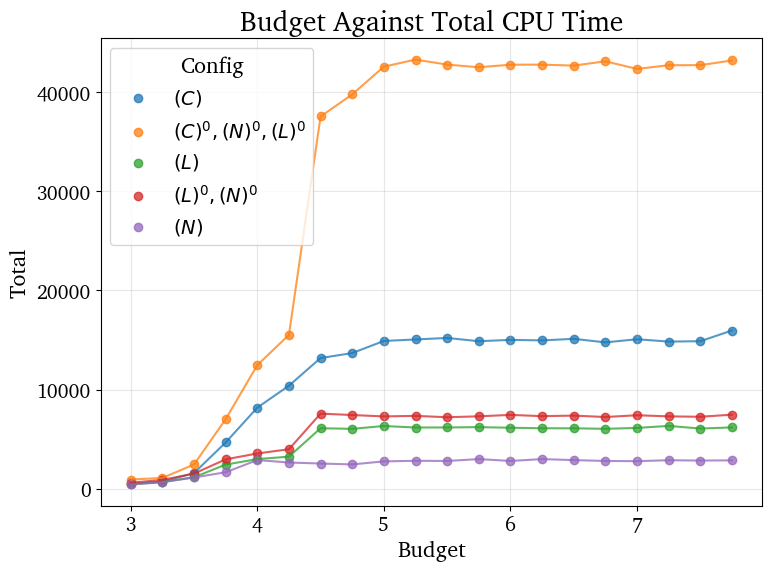

In [79]:
c = ["(C)", "(L)", "(N)", "(L)^0, (N)^0", "(C)^0, (N)^0, (L)^0"]
QuickPlotGraph(df, c, "Budget", "Total", title="Budget Against Total CPU Time", log_scale=False, file_out=f"{er.figuresFolder}/budgetVtime.png")

## Reusable policy-worth plot

**plot_average_worth_by_budget** filters one configuration and horizon, averages worth first within environment repetitions and then equally across repetitions, and optionally normalises every worth dimension to 0–1.

Columns listed in **flip_cols** are reversed after normalisation so larger plotted values consistently mean better outcomes.


In [68]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import MaxNLocator


def plot_average_worth_by_budget(
    df,
    config,
    horizon,
    worth_cols=("Carla", "Necessity", "Legality", "Cost"),
    budget_range=None,
    flip_cols=("Cost",),
    figsize=(8, 6),
    title=None,
    max_budget_ticks=8,
    normalise=True,
    file_out=None,
    colors:dict=None
):
    """
    Plot average policy worth against budget for one configuration
    at a specified horizon.

    Parameters
    ----------
    budget_range : tuple, optional
        Inclusive (min_budget, max_budget), e.g. (3, 6).
        If None, all budgets are plotted.

    flip_cols : iterable of str
        Columns for which lower raw values are better.
        These are reversed after normalisation so that, for every
        line, higher on the graph means better.

    normalise : bool
        Independently min-max normalise each worth dimension to [0, 1].
    """

    plot_df = df.copy()

    # ------------------------------------------------------------
    # Filter configuration and horizon
    # ------------------------------------------------------------
    plot_df = plot_df[
        (plot_df["Config_name"] == config)
        & (plot_df["Horizon"] == horizon)
    ].copy()

    # ------------------------------------------------------------
    # Convert budget to numeric
    # ------------------------------------------------------------
    plot_df["Budget"] = pd.to_numeric(
        plot_df["Budget"],
        errors="coerce",
    )

    # ------------------------------------------------------------
    # Filter budget range
    # ------------------------------------------------------------
    if budget_range is not None:
        min_budget, max_budget = budget_range

        plot_df = plot_df[
            plot_df["Budget"].between(
                min_budget,
                max_budget,
                inclusive="both",
            )
        ].copy()

    if plot_df.empty:
        raise ValueError(
            f"No rows found for config={config!r}, "
            f"horizon={horizon}, "
            f"budget_range={budget_range}"
        )

    # ------------------------------------------------------------
    # Convert Carla and Cost to numeric
    # ------------------------------------------------------------
    for col in ["Carla", "Cost"]:
        if col in plot_df.columns:
            plot_df[col] = pd.to_numeric(
                plot_df[col],
                errors="coerce",
            )

    # ------------------------------------------------------------
    # Convert R=n values into numbers
    # ------------------------------------------------------------
    for col in ["Necessity", "Legality"]:
        if col in plot_df.columns:

            numeric_values = pd.to_numeric(
                plot_df[col],
                errors="coerce",
            )

            rank_values = pd.to_numeric(
                plot_df[col]
                .astype(str)
                .str.extract(
                    r"R\s*=\s*(-?\d+(?:\.\d+)?)",
                    expand=False,
                ),
                errors="coerce",
            )

            plot_df[col] = numeric_values.fillna(rank_values)

    # Only keep requested columns that exist
    worth_cols = [
        col
        for col in worth_cols
        if col in plot_df.columns
    ]

    # ------------------------------------------------------------
    # Average policies within each environment repetition
    # ------------------------------------------------------------
    env_means = (
        plot_df
        .groupby(
            ["Budget", "Env_rep"],
            as_index=False,
        )[worth_cols]
        .mean()
    )

    # ------------------------------------------------------------
    # Average equally across environment repetitions
    # ------------------------------------------------------------
    averaged_df = (
        env_means
        .groupby(
            "Budget",
            as_index=False,
        )[worth_cols]
        .mean()
        .sort_values("Budget")
    )

    # ------------------------------------------------------------
    # Normalise each worth dimension independently
    # ------------------------------------------------------------
    plot_values = averaged_df.copy()

    if normalise:
        for col in worth_cols:

            minimum = averaged_df[col].min()
            maximum = averaged_df[col].max()

            if maximum != minimum:

                normalised = (
                    (averaged_df[col] - minimum)
                    / (maximum - minimum)
                )

                # Lower raw value = better
                if col in flip_cols:
                    normalised = 1 - normalised

                plot_values[col] = normalised

            else:
                # No variation across budgets
                plot_values[col] = 0.5

    # ------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    for col in worth_cols:
        if plot_values[col].notna().any():
            ax.plot(
                plot_values["Budget"],
                plot_values[col],
                marker="o",
                linewidth=2,
                label=col,
                color = colors[col] if col in colors.keys() else None
            )

    ax.set_xlabel("Budget")

    if normalise:
        ax.set_ylabel("Normalised average worth")
        ax.set_ylim(-0.05, 1.05)
    else:
        ax.set_ylabel("Average worth")

    if title is None:
        title = (
            f"Average Worth vs Budget — "
            f"{config}, Horizon = {horizon}"
        )

    ax.set_title(title)

    ax.xaxis.set_major_locator(
        MaxNLocator(nbins=max_budget_ticks)
    )

    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    if (not file_out is None):
        plt.savefig(file_out)
    plt.show()
    


## Policy-level worth DataFrame

**worth_df** comes from **er.GetWorthData** and contains one row per returned policy, including Carla, Necessity, Legality, and Cost worth values.

This cell then replaces **df** with a cleaned copy of **worth_df**, adds numeric Budget, and shortens Config_name. From this point onward, **df** is policy-level data rather than the earlier winning-policy/timing table.

The final cell generates one worth-versus-budget graph per non-moral configuration.


In [69]:
cols = ["Carla", "Necessity", "Legality", "Cost"]
worth_df = pd.DataFrame(er.GetWorthData(worth_tags=cols, envRepetitions=1))
for t in ["Cost", "Carla"]:
    worth_df[t] = pd.to_numeric(worth_df[t])
worth_df = worth_df.drop(columns=["Conf_rep"])
worth_df["Budget"] = pd.to_numeric(
    worth_df["Config_name"]
    .str.extract(r"^(\d+(?:\.\d+)?)_", expand=False)
    .astype(float)
)
#worth_df["Config_name"] = worth_df["Config_name"].str[2:]
df = worth_df.copy()
df["Cost"] = pd.to_numeric(df["Cost"])
df["Budget"] = pd.to_numeric(
    df["Config_name"]
    .str.extract(r"^(\d+(?:\.\d+)?)_", expand=False)
    .astype(float))
df["Config_name"] = df["Config_name"].str.replace(
    r"^\d+(?:\.\d+)?_",
    "",
    regex=True
)
df


,Config_name,Env_rep,Horizon,Moral_policy_idx,Non-acceptability,Carla,Necessity,Legality,Cost,Budget
0,(C),0,7,0,0.0,-39.105,NaN,NaN,-2.7600,3.00
1,(AU),0,7,0,0.0,-39.105,NaN,NaN,-2.7600,3.00
2,"(C)^0, (AU)^0",0,7,0,0.0,-39.105,NaN,NaN,-2.7600,3.00
3,(N),0,7,0,0.0,NaN,R=-5,NaN,-2.7600,3.00
4,(L),0,7,0,0.0,NaN,NaN,R=-5,-2.7600,3.00
...,...,...,...,...,...,...,...,...,...,...
155,(N),0,7,0,0.0,NaN,R=0,NaN,-3.6857,7.75
156,(L),0,7,0,0.0,NaN,NaN,R=0,-4.2849,7.75
157,"(L)^0, (N)^0",0,7,0,0.0,NaN,R=0,R=0,-4.2849,7.75
158,"(C)^0, (N)^0, (L)^0",0,7,0,0.0,0.000,R=0,R=0,-4.2849,7.75


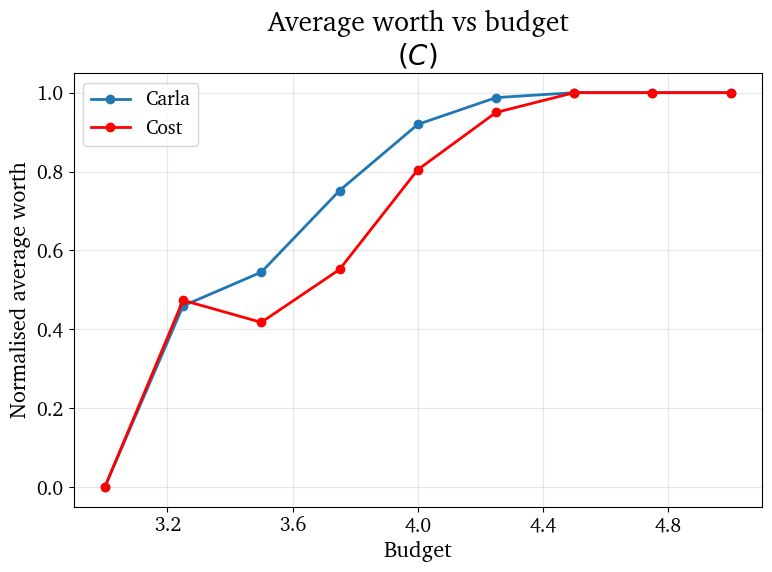

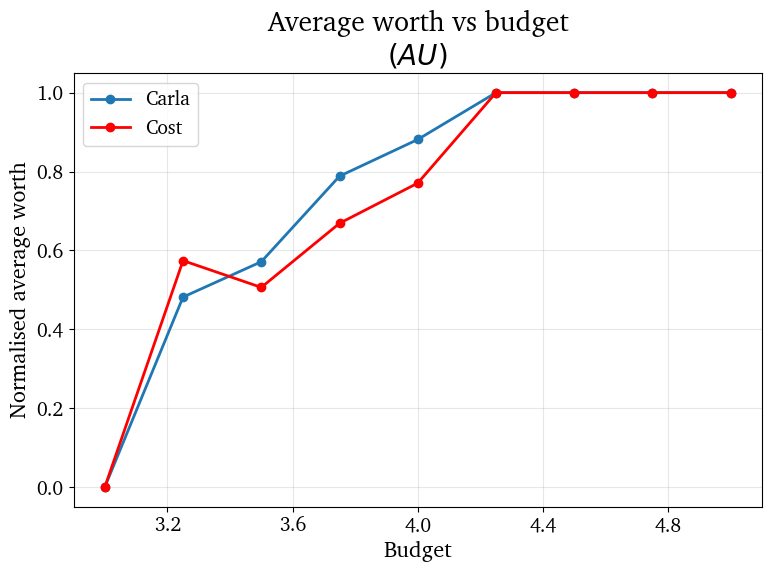

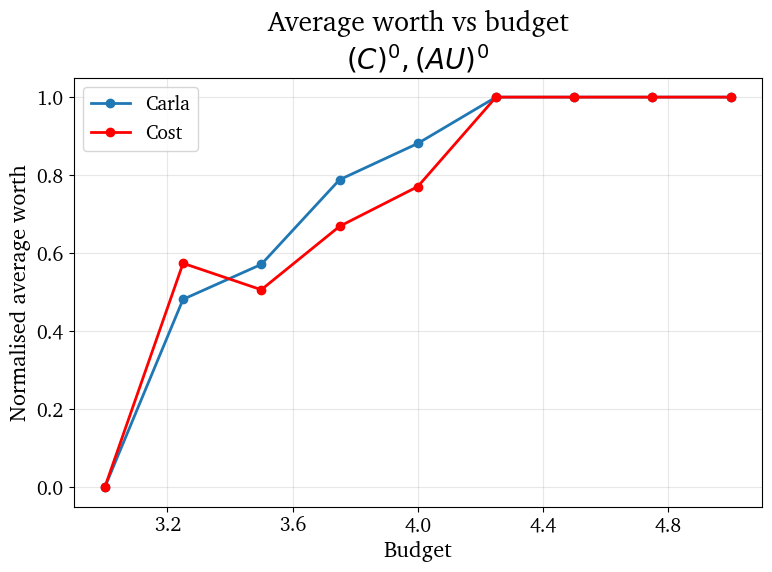

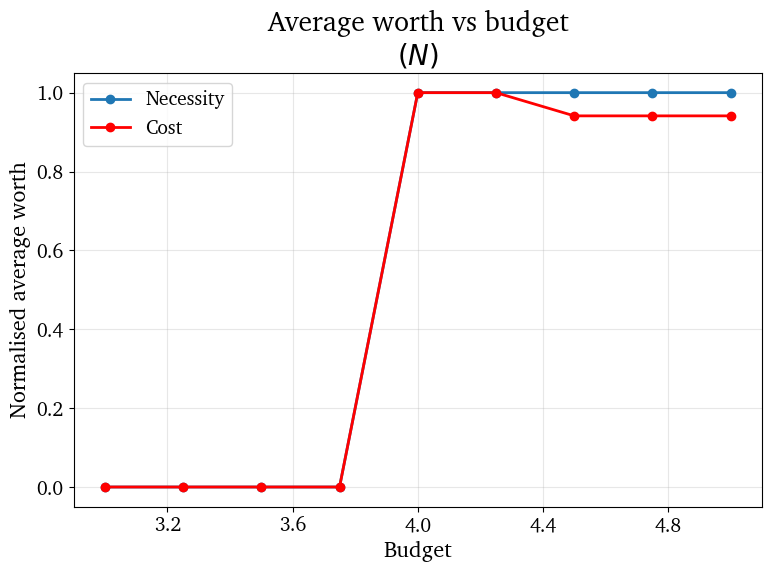

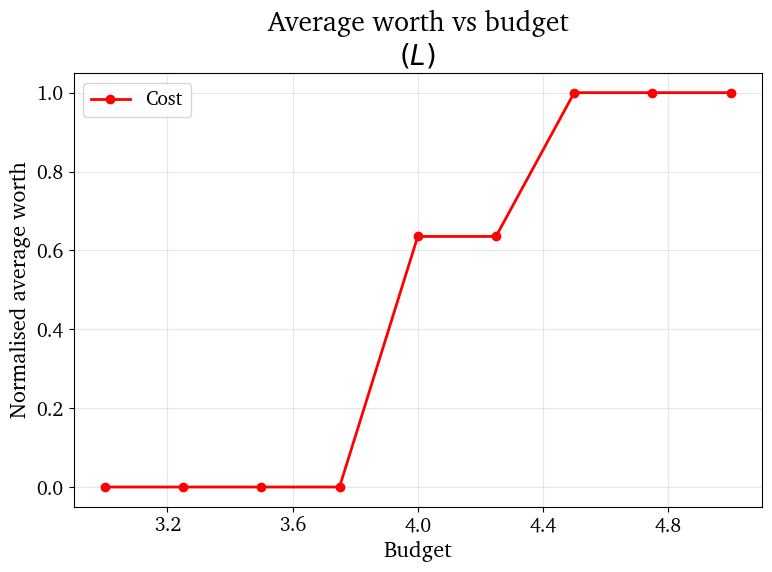

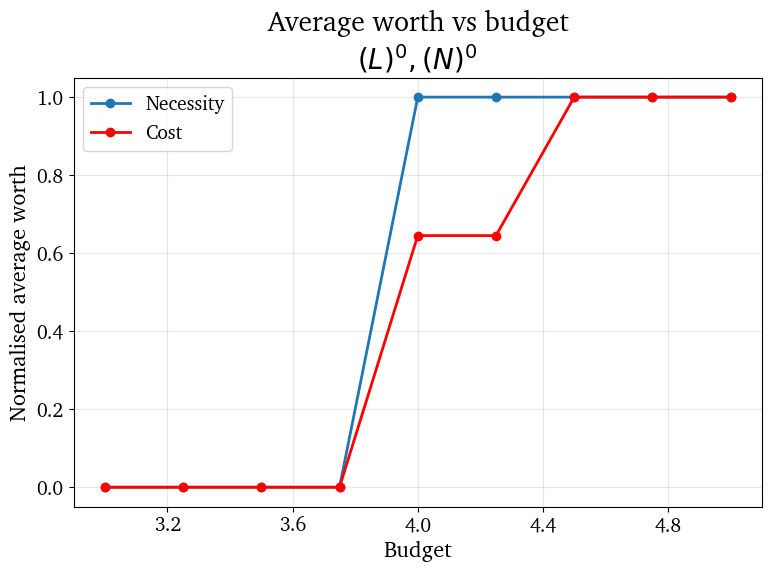

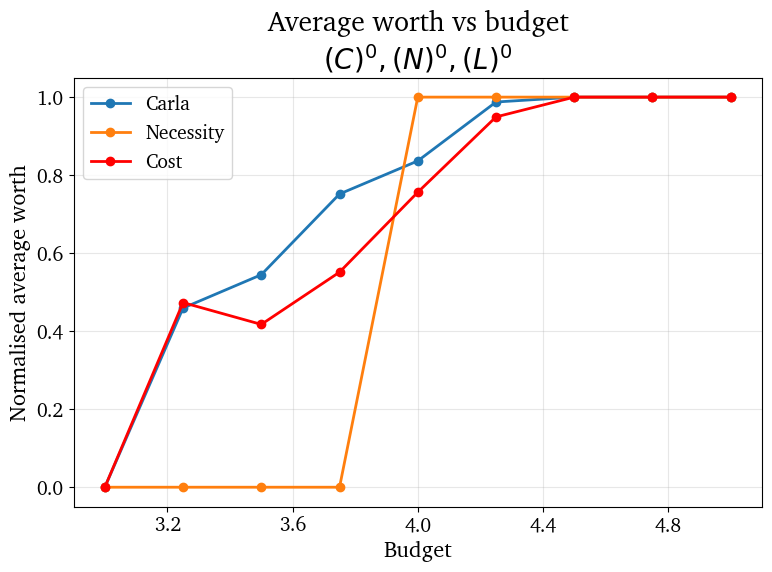

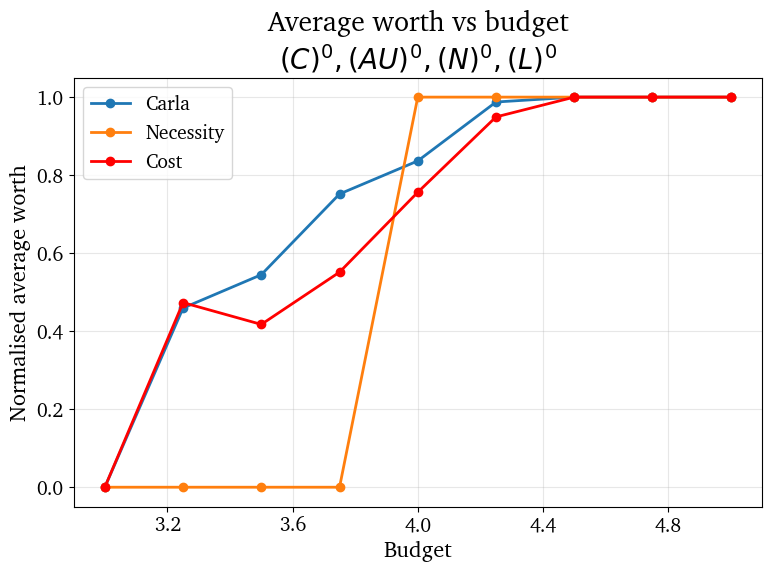

In [75]:
cons = list(nonMoralConfigs.keys())
for c in cons:
    colours = {"Cost": "red"}
    plot_average_worth_by_budget(
        df,
        config=c,
        horizon=7,
        budget_range=(3, 5),
        flip_cols=("Cost",),
        max_budget_ticks=6,
        title=f"Average worth vs budget\n{latex_config_name(c)}",
        file_out=f"{er.figuresFolder}/worthVbudget_C.png",
        colors=colours

    )
